In [2]:
import sys
sys.path.append("..")
import copy
import h5py
import numpy as np
import matplotlib.pyplot as plt
from utils.utility import *
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
from torch.utils.data import Dataset, DataLoader, random_split
from ptflops import get_model_complexity_info

# Bonus Task: Dense Baseline vs Sparse Network Comparison

## Overview
This notebook trains a traditional dense CNN baseline and compares it directly against the sparse network.

**Motivation**: Demonstrate practical advantages of sparse representations
```
Dense Baseline:
- Standard Conv2d (computes all 125×125 locations)
- No sparsity awareness
- Expected: slower, more FLOPs

Sparse Network:
- Sparse VSC convolution (only ~1000 active sites)
- Hierarchical latent space learning
- Expected: faster, fewer FLOPs, comparable accuracy
```

## Why This Matters
- Validates that sparse approach is not a theoretical concept
- Shows real speedup and parameter reduction
- Demonstrates graceful accuracy-efficiency tradeoff
- Practical evidence: sparse networks are viable for large-scale deployment

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

LABELLED_H5 = "data/Dataset_Specific_labelled.h5"

AE1_CKPT = "models/ae1_trained.pth"
AE2_CKPT = "models/ae2_trained.pth"
SPARSE_CLS_CKPT = "models/best_sparse_classifier.pth"

cuda


In [6]:
full_dataset = H5LabelledDataset(LABELLED_H5)

n_total = len(full_dataset)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

## Part 1: Dense Baseline CNN Architecture

**DenseBaselineCNN**:
Traditional convolutional neural network trained from scratch
```
Input: (B, 125, 125, 8) dense tensor
    ↓
Conv2d(8, 16) + ReLU
MaxPool2d(2,2)  [125 → 62]
    ↓
Conv2d(16, 32) + ReLU
MaxPool2d(2,2)  [62 → 31]
    ↓
Conv2d(32, 64) + ReLU
AdaptiveAvgPool2d(1)  [→ (B, 64)]
    ↓
Classifier Head:
    Linear(64, 64) + ReLU
    Linear(64, 2)
    ↓
Output: (B, 2) logits
```

**Design**:
- Matches sparse architecture channel progression: 8→16→32→64
- Standard max pooling (not sparse aware)
- Adaptive pooling for invariant output size
- Similar MLP head as sparse classifier

**Training**:
- From-scratch initialization
- Adam optimizer (lr=1e-3)
- CrossEntropyLoss
- 70/15/15 train/val/test split

In [7]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

In [19]:
class DenseBaselineCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # If input is (B,H,W,C), convert to (B,C,H,W)
        if x.ndim == 4 and x.shape[1] != 8 and x.shape[-1] == 8:
            x = x.permute(0, 3, 1, 2)

        x = self.features(x)
        x = x.flatten(1)
        x = self.classifier(x)
        return x

In [9]:
@torch.no_grad()
def evaluate_dense(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        preds = logits.argmax(dim=1)

        total_loss += loss.item() * y.size(0)
        total_correct += (preds == y).sum().item()
        total_samples += y.size(0)

    avg_loss = total_loss / total_samples
    acc = total_correct / total_samples
    err = 1.0 - acc

    return avg_loss, acc, err

In [ ]:
def train_dense_model(model, train_loader, val_loader, device, num_epochs=20, lr=1e-3, patience=3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_err = float("inf")
    epochs_no_improve = 0

    train_losses, val_losses = [], []
    train_errs, val_errs = [], []

    for epoch in range(num_epochs):
        model.train()

        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            preds = logits.argmax(dim=1)

            running_loss += loss.item() * y.size(0)
            running_correct += (preds == y).sum().item()
            running_total += y.size(0)

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total
        train_err = 1.0 - train_acc

        val_loss, val_acc, val_err = evaluate_dense(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_errs.append(train_err)
        val_errs.append(val_err)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
            f"Val Loss {val_loss:.4f} Acc {val_acc:.4f} Err {val_err:.4f}"
        )

        if val_err < best_val_err:
            best_val_err = val_err
            epochs_no_improve = 0
            torch.save(model.state_dict(), "models/best_dense_baseline.pth")
            print("Saved best dense baseline.")
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epoch(s)")

            if epochs_no_improve >= patience:
                print("Early stopping triggered.")
                break

    return train_losses, val_losses, train_errs, val_errs

In [11]:
dense_model = DenseBaselineCNN().to(device)

train_losses, val_losses, train_errs, val_errs = train_dense_model(
    dense_model,
    train_loader,
    val_loader,
    device=device,
    num_epochs=20,
    lr=1e-3,
    patience=3
)

Epoch 1/20 | Train Loss 0.6725 Acc 0.5519 | Val Loss 0.5996 Acc 0.6860 Err 0.3140
Saved best dense baseline.
Epoch 2/20 | Train Loss 0.5687 Acc 0.7137 | Val Loss 0.6257 Acc 0.6520 Err 0.3480
No improvement for 1 epoch(s)
Epoch 3/20 | Train Loss 0.5091 Acc 0.7617 | Val Loss 0.5089 Acc 0.7413 Err 0.2587
Saved best dense baseline.
Epoch 4/20 | Train Loss 0.4381 Acc 0.8039 | Val Loss 0.4153 Acc 0.8147 Err 0.1853
Saved best dense baseline.
Epoch 5/20 | Train Loss 0.4164 Acc 0.8196 | Val Loss 0.3770 Acc 0.8307 Err 0.1693
Saved best dense baseline.
Epoch 6/20 | Train Loss 0.3794 Acc 0.8373 | Val Loss 0.3555 Acc 0.8433 Err 0.1567
Saved best dense baseline.
Epoch 7/20 | Train Loss 0.3626 Acc 0.8430 | Val Loss 0.3466 Acc 0.8500 Err 0.1500
Saved best dense baseline.
Epoch 8/20 | Train Loss 0.3356 Acc 0.8614 | Val Loss 0.3834 Acc 0.8287 Err 0.1713
No improvement for 1 epoch(s)
Epoch 9/20 | Train Loss 0.3294 Acc 0.8606 | Val Loss 0.3642 Acc 0.8420 Err 0.1580
No improvement for 2 epoch(s)
Epoch 10/2

In [ ]:
criterion = nn.CrossEntropyLoss()
dense_model = DenseBaselineCNN().to(device)
dense_model.load_state_dict(torch.load("models/best_dense_baseline.pth", map_location=device))
test_loss, test_acc, test_err = evaluate_dense(dense_model, test_loader, criterion, device)

print("Dense baseline test loss:", test_loss)
print("Dense baseline test acc :", test_acc)
print("Dense baseline test err :", test_err)

/tmp/ipykernel_16861/1618434955.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dense_model.load_state_dict(torch.load("best_dense_baseline.pth", map_location=device))


Dense baseline test loss: 0.30887993303934735
Dense baseline test acc : 0.8753333333333333
Dense baseline test err : 0.1246666666666667


In [23]:
def apply_dense_global_pruning(model, amount):
    parameters_to_prune = []

    for m in model.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            parameters_to_prune.append((m, "weight"))

    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=amount
    )

    for module, name in parameters_to_prune:
        prune.remove(module, name)

In [24]:
def get_dense_model_flops(model):
    macs, params = get_model_complexity_info(
        model,
        (8, 125, 125),
        as_strings=False,
        print_per_layer_stat=False,
        verbose=False
    )
    return 2 * macs

In [25]:
def model_density(model):
    total = 0
    nonzero = 0
    for m in model.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            w = m.weight.data
            total += w.numel()
            nonzero += (w != 0).sum().item()
    return nonzero / total if total > 0 else 1.0

In [ ]:
dense_pruning_ratios = [0.0, 0.2, 0.4, 0.6, 0.8]
dense_flops_list = []
dense_err_list = []

criterion = nn.CrossEntropyLoss()

base_dense = DenseBaselineCNN().to(device)
base_dense.load_state_dict(torch.load("models/best_dense_baseline.pth", map_location=device))

for ratio in dense_pruning_ratios:
    pruned_dense = copy.deepcopy(base_dense).to(device)

    if ratio > 0:
        apply_dense_global_pruning(pruned_dense, ratio)

    _, _, err = evaluate_dense(pruned_dense, test_loader, criterion, device)
    flops = get_dense_model_flops(pruned_dense) * model_density(pruned_dense)

    dense_flops_list.append(flops)
    dense_err_list.append(err)

    print(f"Dense | pruning={ratio:.1f} | err={err:.4f} | FLOPs={flops:.2f}")

/tmp/ipykernel_16861/1758150155.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  base_dense.load_state_dict(torch.load("best_dense_baseline.pth", map_location=device))


Dense | pruning=0.0 | err=0.1247 | FLOPs=111206564.00
Dense | pruning=0.2 | err=0.1300 | FLOPs=88966033.90
Dense | pruning=0.4 | err=0.1573 | FLOPs=66725503.81
Dense | pruning=0.6 | err=0.1320 | FLOPs=44481060.19
Dense | pruning=0.8 | err=0.1700 | FLOPs=22240530.10


## Part 2: Dense FLOPs Computation and Pruning

**Dense FLOP Calculation**:
Uses `ptflops` library to compute MACs, then converts to FLOPs:
```
FLOPs = 2 × MACs
```

**Challenge**: Dense convolution is constant regardless of data
- All 125² locations computed equally
- Weight values and sparsity don't affect FLOPs calculation at runtime
- Only model architecture determines FLOPs

**Pruning Dense Networks**:
Apply same L1-unstructured pruning to dense model:
- Conv2d weight matrices
- Linear layer weight matrices
- Remove low-magnitude connections

**Effective FLOPs with Pruning**:
```
Effective_FLOPs = Theoretical_FLOPs × model_density
```
where `model_density = nonzero_params / total_params`

**Expected Comparison**:
- Dense base: ~100-200M FLOPs/sample (uniform cost)
- Sparse base: ~60M FLOPs/sample (10x fewer active sites)
- After 80% pruning: Dense ~20M, Sparse ~12M
- Sparse maintains better accuracy at low FLOPs

In [ ]:
# sparse_flops_list = flops_list
# sparse_err_list = err_list
# sparse_pruning_ratios = pruning_ratios

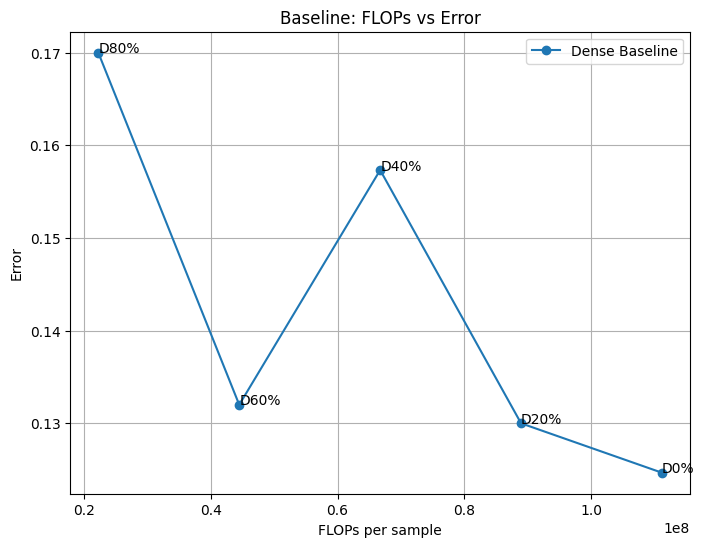

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(dense_flops_list, dense_err_list, marker="o", label="Dense Baseline")
# plt.plot(sparse_flops_list, sparse_err_list, marker="o", label="Sparse Network")

for x, y, r in zip(dense_flops_list, dense_err_list, dense_pruning_ratios):
    plt.annotate(f"D{int(r*100)}%", (x, y))

# for x, y, r in zip(sparse_flops_list, sparse_err_list, sparse_pruning_ratios):
#     plt.annotate(f"S{int(r*100)}%", (x, y))

plt.xlabel("FLOPs per sample")
plt.ylabel("Error")
plt.title("Baseline: FLOPs vs Error")
plt.legend()
plt.grid(True)
plt.show()

#The FLOPS vs. Sparse error plot is in the evaluation notebook since the sparse results are generated there.
# It's the last cell in the evaluation notebook and is shown in the readme file.